# Setup

In [1]:
# Descomentar si se requiere usar google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%capture
!pip install PytorchWildlife
!pip install lightning

In [3]:
from PIL import Image, ImageOps
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from PytorchWildlife.models import detection as pw_detection
from PytorchWildlife.models import classification as pw_classification
from IPython.display import Image as IPImage
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import gc
import time
import torch
from tqdm import tqdm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Path to the training dataset
DATASET_PATH = os.path.join(
    "/content", "drive", "MyDrive", "ECHO", "snapshot_images"
)

# Utils

In [5]:
def load_json(path):
    with open(os.path.join(path), "r") as f:
        return json.load(f)

def save_json(data, path):
    with open(os.path.join(path), "w") as f:
        json.dump(data, f, indent=4)

In [6]:
DIR = 'tmp'
MIN_COUNT = 200
if not os.path.exists(DIR):
    os.mkdir(DIR)
total_species = 0
total_count = 0
classes = {}
for specie in os.listdir(DATASET_PATH):
  specie_path = os.path.join(DATASET_PATH, specie)
  if not os.path.isdir(specie_path):
    continue
  count_files = len(os.listdir(specie_path))
  if count_files < MIN_COUNT:
    continue
  if not classes.get(specie):
    classes[specie] = count_files
  total_species += 1
  total_count += count_files

id_to_specie = {}
specie_to_id = {}
for idx in range(0, len(classes)):
  id_to_specie[idx] = list(classes.keys())[idx]
  specie_to_id[list(classes.keys())[idx]] = idx

for cls, _ in sorted(classes.items(), key=lambda x: -x[1]):
  print(f"[{specie_to_id[cls]}] {cls}: {classes[cls]} ({round(classes[cls] / total_count, 2) * 100}%)")
print(f"Total species: {total_species}")

[0] Hued hued: 500 (8.0%)
[1] Pudu: 500 (8.0%)
[2] Puma: 500 (8.0%)
[4] Chucao: 500 (8.0%)
[5] Zorzal: 500 (8.0%)
[3] Guina: 314 (5.0%)
[8] Guanaco: 275 (4.0%)
[18] Zorro chilla: 255 (4.0%)
[19] Conejo europeo: 253 (4.0%)
[9] Huemul: 245 (4.0%)
[20] Gato domestico: 226 (4.0%)
[13] Vaca: 217 (4.0%)
[14] Zorro culpeo: 215 (3.0%)
[6] Caballo: 214 (3.0%)
[17] Jabali: 211 (3.0%)
[16] Quique: 207 (3.0%)
[12] Perro domestico: 206 (3.0%)
[11] Oveja: 204 (3.0%)
[10] Liebre europea: 203 (3.0%)
[15] Vison americano: 203 (3.0%)
[7] Chingue: 201 (3.0%)
Total species: 21


# Preprocessing

## Example

In [ ]:
from random import choice

# Example detection and expected output
ex_img = choice(os.listdir(os.path.join(DATASET_PATH, id_to_specie[0])))
example_path = os.path.join(DATASET_PATH, id_to_specie[0], ex_img)
results = detector.single_image_detection(example_path)
detections = results["detections"].xyxy
confidences = results["detections"].confidence
image = Image.open(example_path)
draw = ImageDraw.Draw(image)

for bbox, conf in zip(detections, confidences):
  print(bbox, conf)
  x0,y0,x1,y1 = bbox
  draw.rectangle([(x0, y0), (x1, y1)], outline="red", width=8)

  draw.text((x0, y0-20), f"{conf:.2f}", fill="red")
  crop = image.crop((x0, y0, x1, y1))
  crop.save("/tmp/example_crop.jpg")
  image.save("/tmp/example_original.jpg")



0: 1280x1280 1 animal, 15061.4ms
Speed: 25.6ms preprocess, 15061.4ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 1280)
[     403.74      668.29      495.49      794.75] 0.8413252


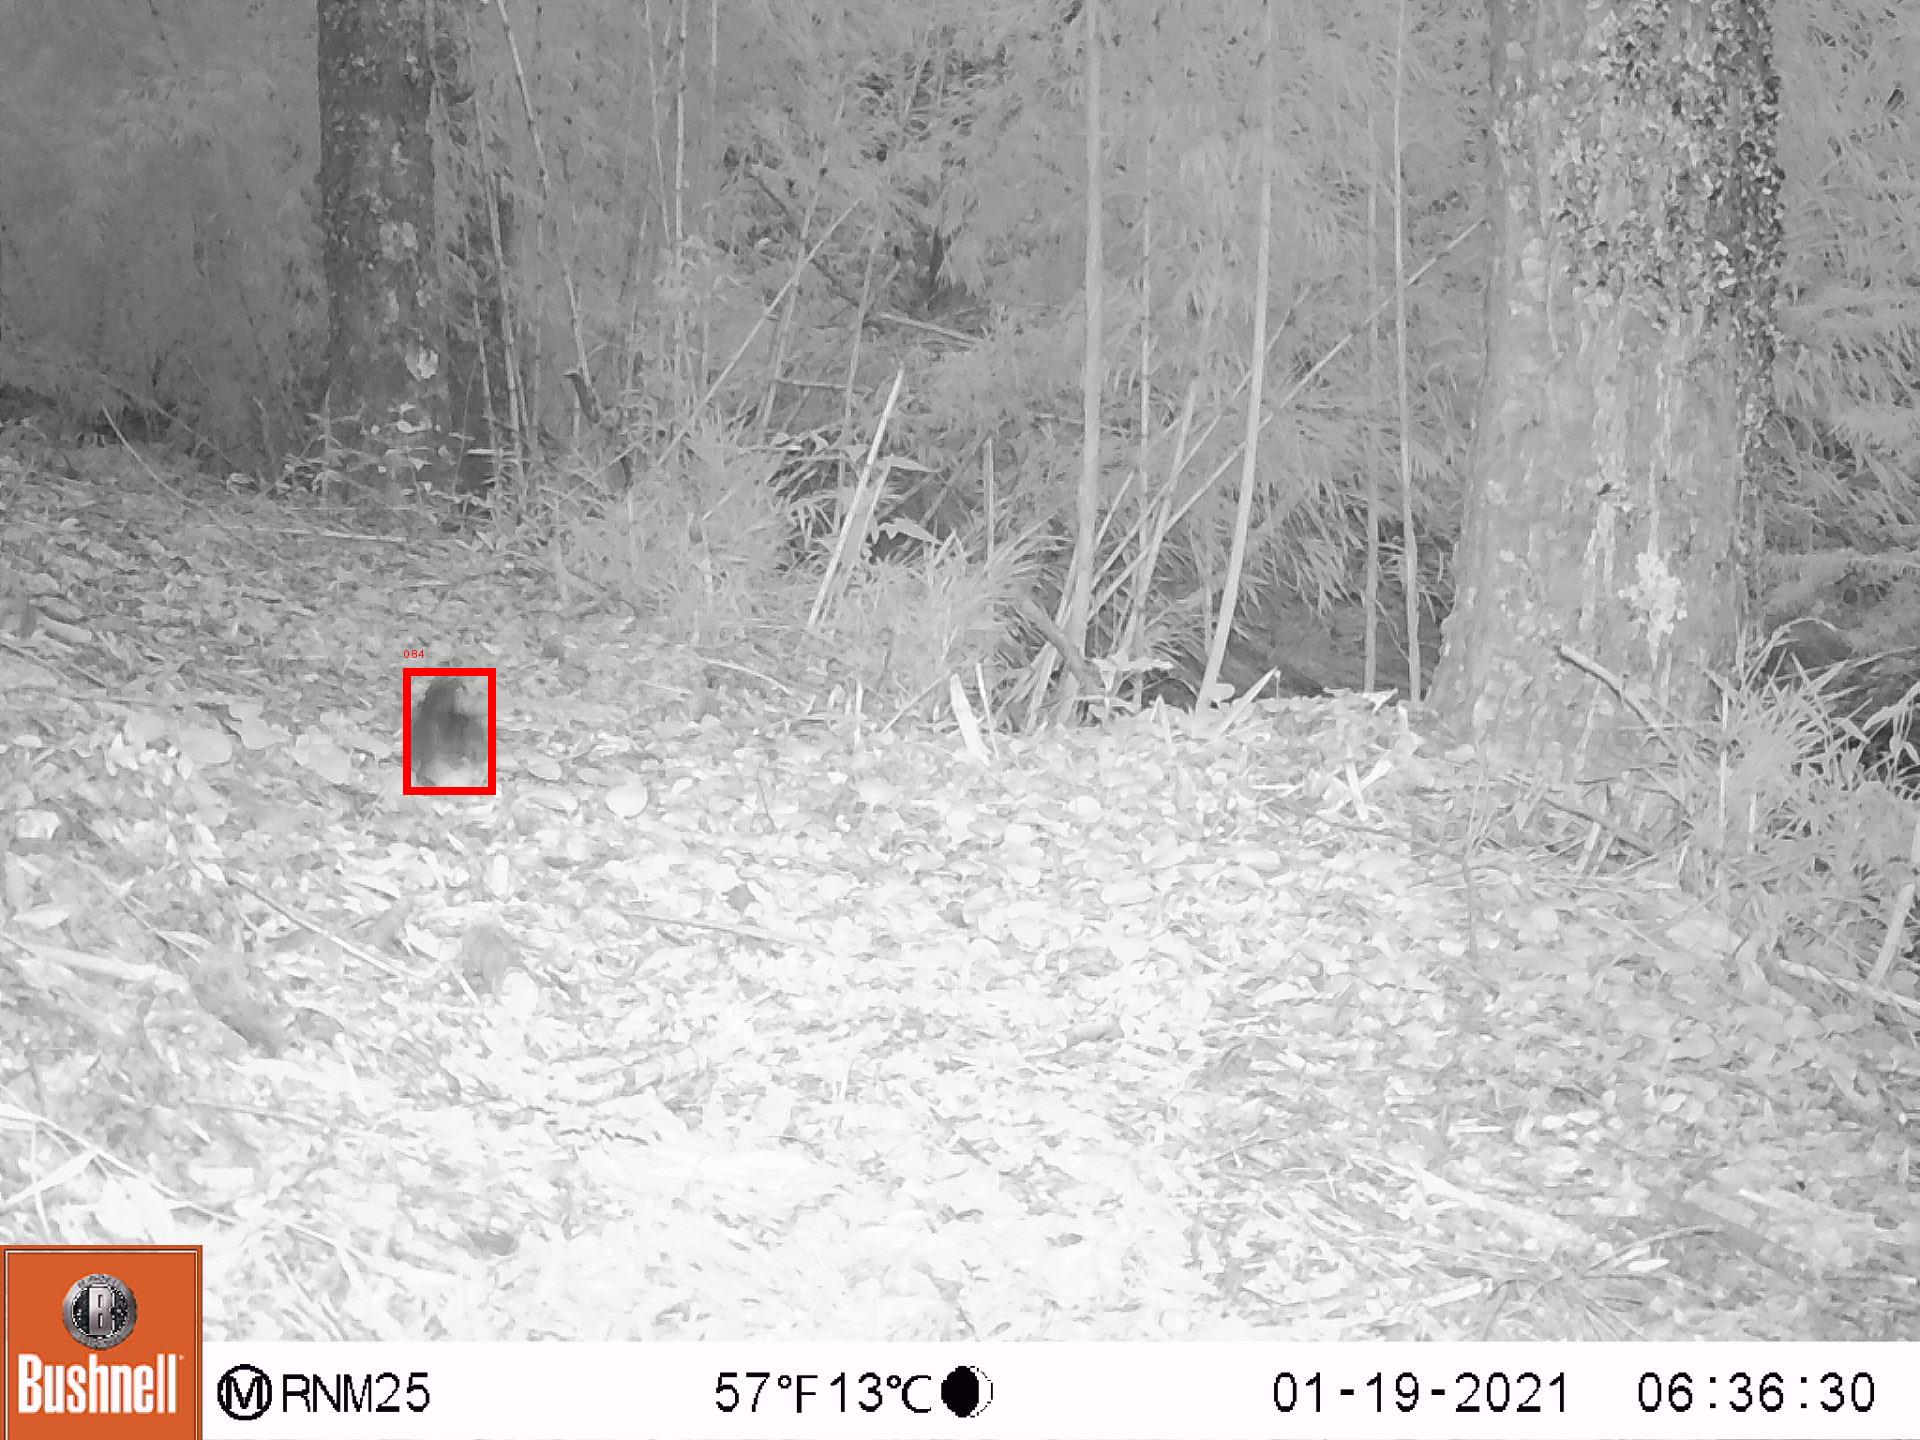

In [ ]:
IPImage("/tmp/example_original.jpg")

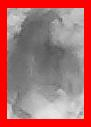

In [ ]:
IPImage("/tmp/example_crop.jpg")

## Cropping

In [7]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA available: True
GPU: Tesla T4


In [8]:
DET_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

detector = pw_detection.MegaDetectorV6(
    device=DET_DEVICE,
    version="MDV6-yolov10-e"
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10x summary (fused): 191 layers, 29,399,417 parameters, 0 gradients, 160.0 GFLOPs


In [ ]:
# Utils
def load_json(path):
    if not os.path.exists(path):
        return {}

    with open(path, "r") as f:
        return json.load(f)


def save_json(data, path):
    tmp_path = path + ".tmp"

    with open(tmp_path, "w") as f:
        json.dump(data, f, indent=4)

    os.replace(tmp_path, path)


def to_serializable_array(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()

    if hasattr(x, "tolist"):
        return x.tolist()

    return list(x)


def cleanup_memory(force_cuda=False):
    gc.collect()

    if force_cuda and torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_existing_local_idx(class_metadata):
    return len(class_metadata)


In [12]:
DEST_PATH = os.path.join("/content", "tmp")
METADATA_FILENAME = "detections_metadata.json"
METADATA_PATH = os.path.join(DEST_PATH, METADATA_FILENAME)

SAVE_EVERY = 25
DEBUG_MAX_CLASSES = None
DEBUG_MAX_IMAGES_PER_CLASS = None

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

os.makedirs(DEST_PATH, exist_ok=True)


detections_metadata = load_json(METADATA_PATH)

global_start = time.time()
class_counter = 0


for cls in classes:
    if DEBUG_MAX_CLASSES is not None and class_counter >= DEBUG_MAX_CLASSES:
        break

    cls_idx = str(specie_to_id[cls])

    cls_path = os.path.join(DEST_PATH, cls_idx)
    source_path = os.path.join(DATASET_PATH, cls)

    os.makedirs(cls_path, exist_ok=True)

    if cls_idx not in detections_metadata:
        detections_metadata[cls_idx] = {}

    images = sorted([
        img_name
        for img_name in os.listdir(source_path)
        if img_name.endswith(VALID_EXTENSIONS)
    ])

    pending_images = [
        img_name
        for img_name in images
        if img_name not in detections_metadata[cls_idx]
    ]

    if DEBUG_MAX_IMAGES_PER_CLASS is not None:
        pending_images = pending_images[:DEBUG_MAX_IMAGES_PER_CLASS]

    print(f"\nClass: {cls} / ID: {cls_idx}")
    print(f"Total images: {len(images)}")
    print(f"Pending images: {len(pending_images)}")

    if len(pending_images) == 0:
        print(f"Class {cls} already processed.")
        class_counter += 1
        continue

    processed_since_save = 0
    class_start = time.time()

    for img_name in tqdm(pending_images, desc=f"Detecting {cls}"):
        img_path = os.path.join(source_path, img_name)

        local_idx = get_existing_local_idx(detections_metadata[cls_idx])
        dest_img_path = os.path.join(cls_path, f"{local_idx}.jpg")
        if detections_metadata[cls_idx].get(img_name):
            print(f"Image {img_name} already exists at {cls_idx}.")
            continue

        try:
            img_start = time.time()

            with torch.inference_mode():
                result = detector.single_image_detection(img_path)

            detections = result["detections"].xyxy
            confidences = result["detections"].confidence

            detections_metadata[cls_idx][img_name] = {
                "class_name": cls,
                "class_id": cls_idx,
                "source_img_path": img_path,
                "dest_img_path": dest_img_path,
                "detections": to_serializable_array(detections),
                "confidences": to_serializable_array(confidences),
                "detection_time_sec": round(time.time() - img_start, 4),
            }

            processed_since_save += 1

            if processed_since_save >= SAVE_EVERY:
                save_json(detections_metadata, METADATA_PATH)
                processed_since_save = 0
                cleanup_memory(force_cuda=False)

        except Exception as e:
            print(f"\nError processing image: {img_path}")
            print(f"Error: {e}")
            save_json(detections_metadata, METADATA_PATH)
            cleanup_memory(force_cuda=True)
            continue

        finally:
            if "result" in locals():
                del result

    save_json(detections_metadata, METADATA_PATH)

    elapsed_class = time.time() - class_start
    print(f"Class {cls} stored successfully at {cls_path}")
    print(f"Class elapsed time: {elapsed_class / 60:.2f} minutes")

    cleanup_memory(force_cuda=True)
    class_counter += 1


total_elapsed = time.time() - global_start

print("\nDetection metadata generation finished.")
print(f"Metadata saved at: {METADATA_PATH}")
print(f"Total elapsed time: {total_elapsed / 60:.2f} minutes")


Class: Hued hued / ID: 0
Total images: 500
Pending images: 1


Detecting Hued hued:   0%|          | 0/1 [00:00<?, ?it/s]


Error processing image: /content/drive/MyDrive/ECHO/snapshot_images/Hued hued/2023 01 23 09 58 37.jpg.png
Error: cannot identify image file '/content/drive/MyDrive/ECHO/snapshot_images/Hued hued/2023 01 23 09 58 37.jpg.png'


Detecting Hued hued: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


Class Hued hued stored successfully at /content/tmp/0
Class elapsed time: 0.01 minutes

Class: Pudu / ID: 1
Total images: 500
Pending images: 1


...

Detecting Gato domestico: 100%|█████████▉| 225/226 [01:30<00:00,  1.74it/s]


0: 1280x1280 1 animal, 239.2ms
Speed: 16.2ms preprocess, 239.2ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 1280)


Detecting Gato domestico: 100%|██████████| 226/226 [01:30<00:00,  2.49it/s]

Class Gato domestico stored successfully at /content/tmp/20
Class elapsed time: 1.52 minutes



Detection metadata generation finished.
Metadata saved at: /content/tmp/detections_metadata.json
Total elapsed time: 4.62 minutes


# Cropping


In [13]:
CROP_REPORT_PATH = os.path.join(DEST_PATH, "crop_report.json")

IMAGE_SIZE = 224
CONF_THRESHOLD = 0.25
PADDING_RATIO = 0.10

MAX_WORKERS = 4  # Prueba 2, 4, 8. En Colab usaría 4.

def clamp(value, min_value, max_value):
    return max(min_value, min(value, max_value))


def get_best_detection(detections, confidences):
    if len(detections) == 0 or len(confidences) == 0:
        return None, None

    best_idx = max(range(len(confidences)), key=lambda i: confidences[i])
    best_conf = confidences[best_idx]
    best_bbox = detections[best_idx]

    return best_bbox, best_conf


def prepare_bbox(bbox, img_width, img_height, padding_ratio=0.10):
    x1, y1, x2, y2 = bbox

    # Si los valores vienen normalizados entre 0 y 1
    if max(x1, y1, x2, y2) <= 1.0:
        x1 *= img_width
        x2 *= img_width
        y1 *= img_height
        y2 *= img_height

    x1, y1, x2, y2 = float(x1), float(y1), float(x2), float(y2)

    box_width = x2 - x1
    box_height = y2 - y1

    padding_x = box_width * padding_ratio
    padding_y = box_height * padding_ratio

    x1 = int(clamp(x1 - padding_x, 0, img_width))
    y1 = int(clamp(y1 - padding_y, 0, img_height))
    x2 = int(clamp(x2 + padding_x, 0, img_width))
    y2 = int(clamp(y2 + padding_y, 0, img_height))

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2


def crop_one_image(task):
    class_id = task["class_id"]
    img_name = task["img_name"]
    source_img_path = task["source_img_path"]
    dest_img_path = task["dest_img_path"]
    detections = task["detections"]
    confidences = task["confidences"]

    if os.path.exists(dest_img_path):
        return {
            "class_id": class_id,
            "img_name": img_name,
            "status": "skipped_exists",
            "dest_img_path": dest_img_path,
        }

    best_bbox, best_conf = get_best_detection(detections, confidences)

    if best_bbox is None:
        return {
            "class_id": class_id,
            "img_name": img_name,
            "status": "no_detection",
            "dest_img_path": dest_img_path,
        }

    if best_conf < CONF_THRESHOLD:
        return {
            "class_id": class_id,
            "img_name": img_name,
            "status": "low_confidence",
            "confidence": best_conf,
            "dest_img_path": dest_img_path,
        }

    try:
        os.makedirs(os.path.dirname(dest_img_path), exist_ok=True)

        with Image.open(source_img_path) as img:
            img = ImageOps.exif_transpose(img)
            img = img.convert("RGB")

            img_width, img_height = img.size

            bbox = prepare_bbox(
                best_bbox,
                img_width,
                img_height,
                padding_ratio=PADDING_RATIO,
            )

            if bbox is None:
                return {
                    "class_id": class_id,
                    "img_name": img_name,
                    "status": "invalid_bbox",
                    "confidence": best_conf,
                    "dest_img_path": dest_img_path,
                }

            cropped = img.crop(bbox)
            cropped = cropped.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.LANCZOS)
            cropped.save(dest_img_path, quality=90, optimize=True)

        return {
            "class_id": class_id,
            "img_name": img_name,
            "status": "ok",
            "confidence": best_conf,
            "bbox": bbox,
            "dest_img_path": dest_img_path,
        }

    except Exception as e:
        return {
            "class_id": class_id,
            "img_name": img_name,
            "status": "error",
            "error": str(e),
            "dest_img_path": dest_img_path,
        }

detections_metadata = load_json(METADATA_PATH)
tasks = []

for class_id, class_data in detections_metadata.items():
    for img_name, item in class_data.items():
        tasks.append({
            "class_id": class_id,
            "img_name": img_name,
            "source_img_path": item["source_img_path"],
            "dest_img_path": item["dest_img_path"],
            "detections": item["detections"],
            "confidences": item["confidences"],
        })

print(f"Total crop tasks: {len(tasks)}")

crop_report = {
    "ok": 0,
    "skipped_exists": 0,
    "no_detection": 0,
    "low_confidence": 0,
    "invalid_bbox": 0,
    "error": 0,
    "items": [],
}

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [
        executor.submit(crop_one_image, task)
        for task in tasks
    ]

    for future in tqdm(as_completed(futures), total=len(futures), desc="Cropping images"):
        result = future.result()
        status = result["status"]

        if status not in crop_report:
            crop_report[status] = 0

        crop_report[status] += 1
        crop_report["items"].append(result)


# -----------------------------
# Save report
# -----------------------------
save_json(crop_report, CROP_REPORT_PATH)

print("\nCropping finished.")
print(f"OK: {crop_report['ok']}")
print(f"Skipped existing: {crop_report['skipped_exists']}")
print(f"No detection: {crop_report['no_detection']}")
print(f"Low confidence: {crop_report['low_confidence']}")
print(f"Invalid bbox: {crop_report['invalid_bbox']}")
print(f"Errors: {crop_report['error']}")
print(f"Report saved at: {CROP_REPORT_PATH}")

Total crop tasks: 6147


Cropping images: 100%|██████████| 6147/6147 [18:36<00:00,  5.51it/s]



Cropping finished.
OK: 5721
Skipped existing: 0
No detection: 359
Low confidence: 67
Invalid bbox: 0
Errors: 0
Report saved at: /content/tmp/crop_report.json


In [14]:
!zip -r preprocessed_images.zip /content/tmp

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  adding: content/tmp/19/55.jpg (deflated 0%)
  adding: content/tmp/19/85.jpg (deflated 0%)
  adding: content/tmp/19/40.jpg (deflated 0%)
  adding: content/tmp/19/44.jpg (deflated 0%)
  adding: content/tmp/19/202.jpg (deflated 0%)
  adding: content/tmp/19/141.jpg (deflated 0%)
  adding: content/tmp/19/174.jpg (deflated 0%)
  adding: content/tmp/19/19.jpg (deflated 0%)
  adding: content/tmp/19/60.jpg (deflated 0%)
  adding: content/tmp/19/34.jpg (deflated 0%)
  adding: content/tmp/19/137.jpg (deflated 1%)
  adding: content/tmp/19/14.jpg (deflated 0%)
  adding: content/tmp/19/50.jpg (deflated 0%)
  adding: content/tmp/19/38.jpg (deflated 1%)
  adding: content/tmp/19/136.jpg (deflated 0%)
  adding: content/tmp/19/208.jpg (deflated 0%)
  adding: content/tmp/19/94.jpg (deflated 0%)
  adding: content/tmp/19/140.jpg (deflated 0%)
  adding: content/tmp/19/131.jpg (deflated 0%)
  adding: content/tmp/19/226.jpg (deflated 1%)
  ad